In [4]:
import cairn as cn
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt


from cairn.utils import prepare_discrete_colour_palette

In [5]:
# Import metadata
df_samples = pd.read_csv('/scratch/user/uqtdenni/far_hin_1.x/work/metadata_development_20250702/metadata-staged-cohorts-20251119.txt',sep='\t')


In [6]:
df_samples.groupby(
    ['taxon_pca','country','admin1_name','latitude','longitude']
).size().to_frame('count').to_csv('sample_locations.csv')

In [7]:
def plot_static_map(df, title, color, extent=[125, 171, -25, 0]):
    
    # Prepare colors
    color_data_unique_values = df[color].unique()

    # Get corresponding number of colours from Paired
    color_discrete_map = list(sns.color_palette("Paired",n_colors=len(color_data_unique_values)).as_hex())
    
    # Map values to colors.
    color_discrete_map_prepped = {
        v: c
        for v, c in zip(
            color_data_unique_values,
            cycle(color_discrete_map),
            strict=False
        )
    }
    
    # Create map with cartopy
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.OCEAN, color='lightblue')
    ax.add_feature(cfeature.LAND, color='lightgray')
    
    # Set extent [west, east, south, north]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Plot points colored by factor
    for level in df[color].unique():
        data = df[df[color] == level]
        point_color = color_discrete_map_prepped.get(level, '#000000')  # Changed variable name
        ax.scatter(data['longitude'], data['latitude'], 
                   transform=ccrs.PlateCarree(), 
                   label=level, s=70, alpha=0.9, c=point_color,edgecolors='black', linewidths=0.5)

    
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.title(f'Species: {title}')
    plt.show()

def plot_interactive_map(df, title, color, color_discrete_map = None, extent=[125, 171, -25, 0]):
    """
    Create an interactive Plotly map with hover data.
    
    Parameters:
    -----------
    df : DataFrame
        Must contain columns: 'longitude', 'latitude', 'sample_id', 'admin1_iso', 
        and the column specified in 'color'
    title : str
        Title for the plot
    color : str
        Column name to use for coloring points
    extent : list
        Map bounds [west, east, south, north]
    """
    
    # Check for no color.
    if color is None:
        # Bail out early.
        return None, None, None

    # Now set up color choices.
    if color_discrete_map is None:
        color_discrete_map_prepped = prepare_discrete_colour_palette(df, color)
    
    else:
        color_discrete_map_prepped = color_discrete_map
    
    # Create interactive map
    fig = px.scatter_map(
        df,
        lat='latitude',
        lon='longitude',
        color=color,
        color_discrete_map=color_discrete_map_prepped,
        hover_data={
            'sample_id': True,
            'admin1_iso': True,
            'latitude': ':.4f',
            'longitude': ':.4f',
            color: True
        },
        title=f'Species: {title}',
        zoom=3,
        height=600,
        width=1000
    )
    
    # Calculate center from extent
    center_lat = (extent[2] + extent[3]) / 2
    center_lon = (extent[0] + extent[1]) / 2
    
    # Update map layout
    fig.update_layout(
        map=dict(
            style="basic",
            center=dict(lat=center_lat, lon=center_lon),
            zoom=3.5
        ),
        margin=dict(l=0, r=0, t=40, b=0)
    )

    # Update marker styling
    fig.update_traces(
        marker=dict(
            size=12,
            opacity=0.7,
            #line=dict(width=1, color='black')
        )
    )
    
    #fig.show()
    
    return fig


def plot_static_topo_map_hq(df, title, color, extent=[125, 171, -25, 0]):
    
    # Prepare colors
    color_data_unique_values = df[color].unique()
    color_discrete_map = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)).as_hex())
    
    color_discrete_map_prepped = {
        v: c
        for v, c in zip(
            color_data_unique_values,
            cycle(color_discrete_map),
            strict=False
        )
    }
    
    # Create map
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Set extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Add high-resolution shaded relief from Natural Earth
    # This downloads once (~50MB), then it's cached forever
    ax.add_feature(cfeature.NaturalEarthFeature(
        'raster', 'shaded_relief', '10m',
        edgecolor='none'), zorder=0)
    
    # Overlay physical features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', zorder=2)
    ax.add_feature(cfeature.LAKES, alpha=0.3, zorder=1)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.5, zorder=1)
    
    # Plot points
    for level in df[color].unique():
        data = df[df[color] == level]
        point_color = color_discrete_map_prepped.get(level, '#000000')
        ax.scatter(data['longitude'], data['latitude'], 
                   transform=ccrs.PlateCarree(), 
                   label=level, s=70, alpha=0.9, c=point_color,
                   edgecolors='black', linewidths=0.5, zorder=5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='white', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.title(f'Species: {title}')
    plt.show()

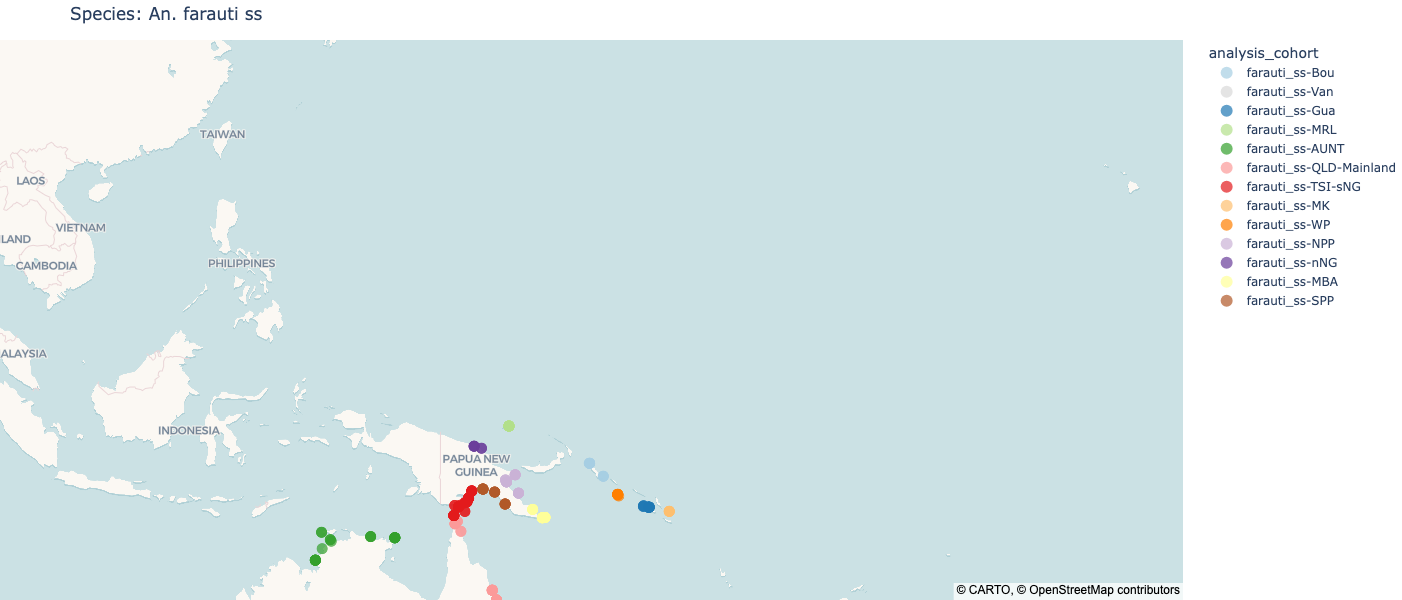

In [8]:
#An farauti ss
subset_df = df_samples.query('taxon_pca == "farauti_ss"')
color_data_unique_values = subset_df.analysis_cohort.unique()

# Make custom farauti pal
pal = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)-1).as_hex())#
pal.insert(1,"#d9d9d9") # add grey where vanuatu is
far_discrete_map_prepped = {
    v: c
    for v, c in zip(
        color_data_unique_values,
        cycle(pal),
        strict=False
    )
}


#plot_static_map(subset_df, title = "An. farauti ss", color="analysis_cohort", extent=[125, 171, -23, 0])
plot_interactive_map(subset_df, title = "An. farauti ss", color_discrete_map = far_discrete_map_prepped, color="analysis_cohort", extent=[125, 175, -13, -5])

Map saved to: topomap.svg


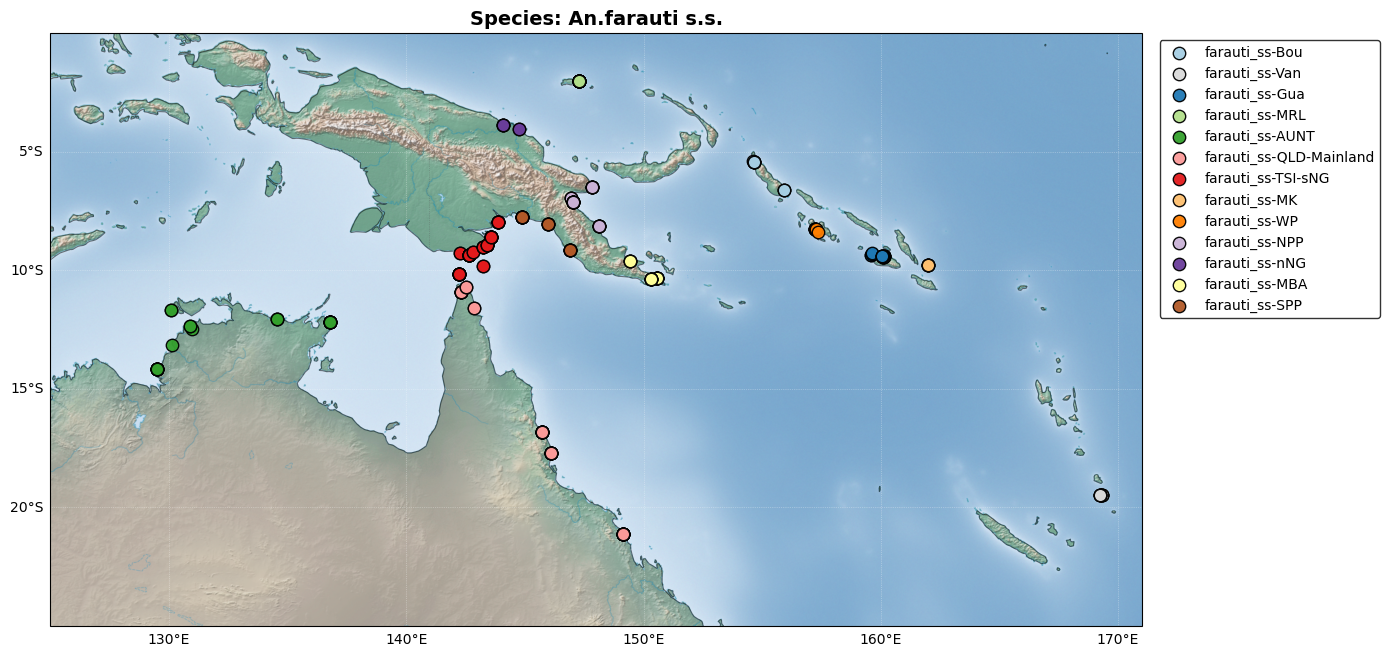

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import rasterio
import numpy as np

def plot_static_topo_map(df, title, color, color_discrete_map, save_path, extent=[125, 171, -25, 0]):

    # Check for no color.
    if color is None:
        # Bail out early.
        return None, None, None

    # Now set up color choices.
    if color_discrete_map is None:
        color_discrete_map_prepped = prepare_discrete_colour_palette(df, color)
    
    else:
        color_discrete_map_prepped = color_discrete_map
    
    # Path to your Natural Earth raster
    ne_raster_path = '/scratch/user/uqtdenni/far_hin_1.x/work/pop_gen_2025/stash/naturalearthdata/HYP_HR_SR_W_DR.tif'
    
    # Create map
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Load and display Natural Earth raster
    try:
        with rasterio.open(ne_raster_path) as src:
            # Read the raster
            img = src.read()
            
            # Get extent
            img_extent = [src.bounds.left, src.bounds.right, 
                         src.bounds.bottom, src.bounds.top]
            
            # Prepare image for display (convert from bands-first to bands-last)
            if img.shape[0] == 3:  # RGB
                img_plot = np.transpose(img, (1, 2, 0))
            elif img.shape[0] == 4:  # RGBA
                img_plot = np.transpose(img, (1, 2, 0))
            else:
                img_plot = img[0]
            
            # Display the raster
            ax.imshow(img_plot, extent=img_extent, 
                     transform=ccrs.PlateCarree(),
                     origin='upper', zorder=0, interpolation='bilinear')
            
    except Exception as e:
        print(f"Error loading raster: {e}")
        # Fallback to simple colors
        ax.add_feature(cfeature.OCEAN, facecolor='#d4f1f9', zorder=0)
        ax.add_feature(cfeature.LAND, facecolor='#f5ead6', zorder=1)
    
    # Add coastlines and borders for definition
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', 
                   alpha=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', 
                   edgecolor='#555555', alpha=0.5, zorder=3)
    
    # Plot points
    for level in df[color].unique():
        data = df[df[color] == level]
        point_color = color_discrete_map_prepped.get(level, '#000000')
        ax.scatter(data['longitude'], data['latitude'], 
                   transform=ccrs.PlateCarree(), 
                   label=level, s=80, alpha=0.95, c=point_color,
                   edgecolors='black', linewidths=1, zorder=5)
    
    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='white', 
                      alpha=0.5, linestyle=':')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True,
              facecolor='white', edgecolor='black')
    plt.title(f'Species: {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
        print(f"Map saved to: {save_path}")
    else:
        plt.show()

    plt.show()
    
plot_static_topo_map(subset_df, title = "An.farauti s.s.", color = "analysis_cohort", save_path = 'topomap.svg', color_discrete_map = far_discrete_map_prepped)

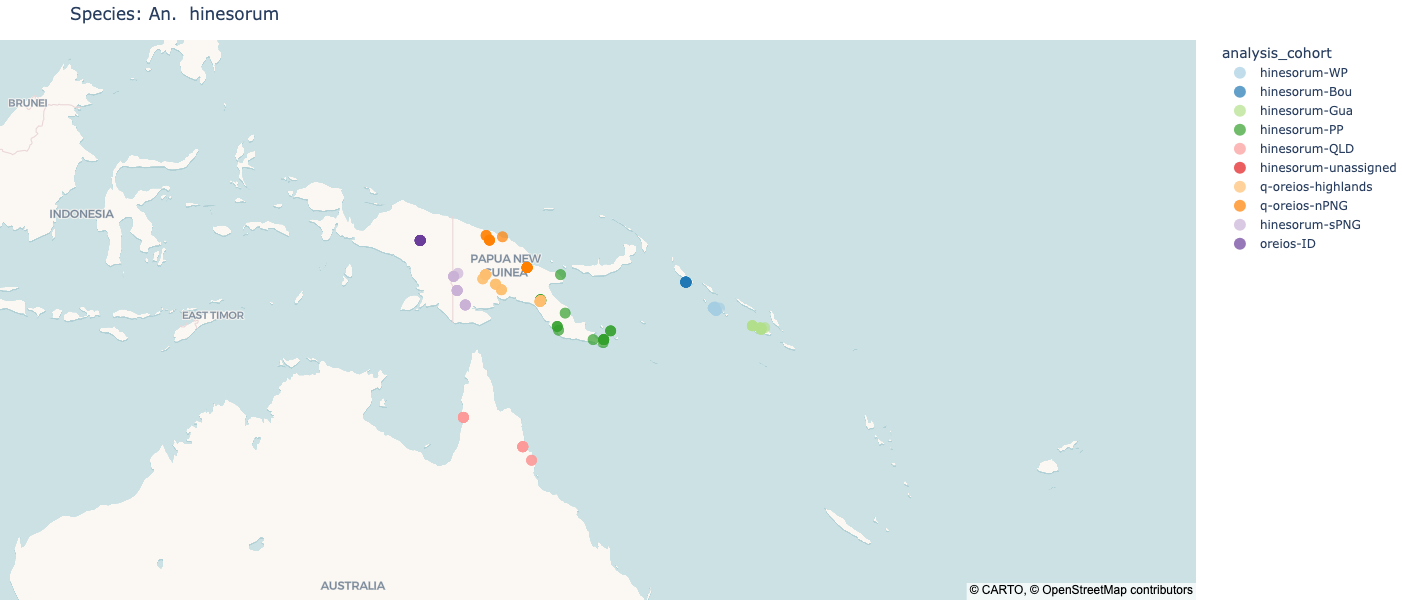

In [6]:
#An farauti ss
subset_df = df_samples.query('taxon_pca in ["hinesorum","oreios"]')
plot_interactive_map(subset_df, title = "An.  hinesorum", color="analysis_cohort", extent=[125, 175, -13, -5])

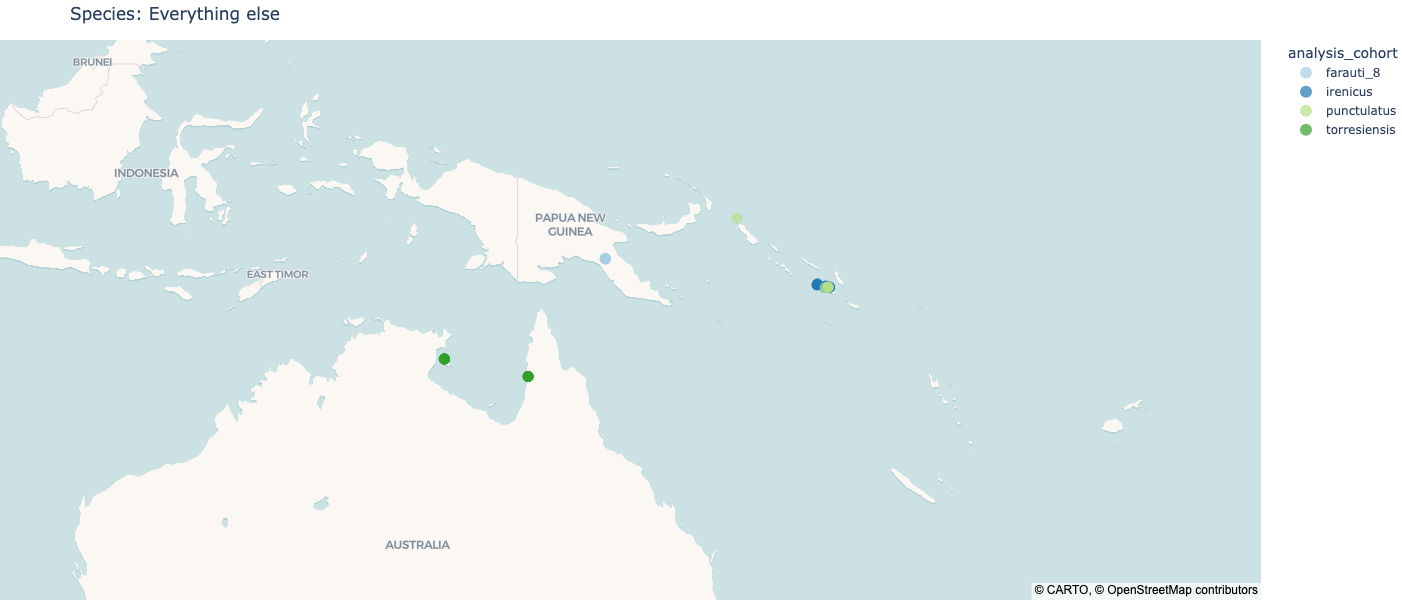

In [7]:
#Everything else
subset_df = df_samples.query('taxon_pca in ["punctulatus", "farauti_8", "irenicus", "torresiensis"]')
plot_interactive_map(subset_df, title = "Everything else", color="analysis_cohort", extent=[125, 171, -23, 0])

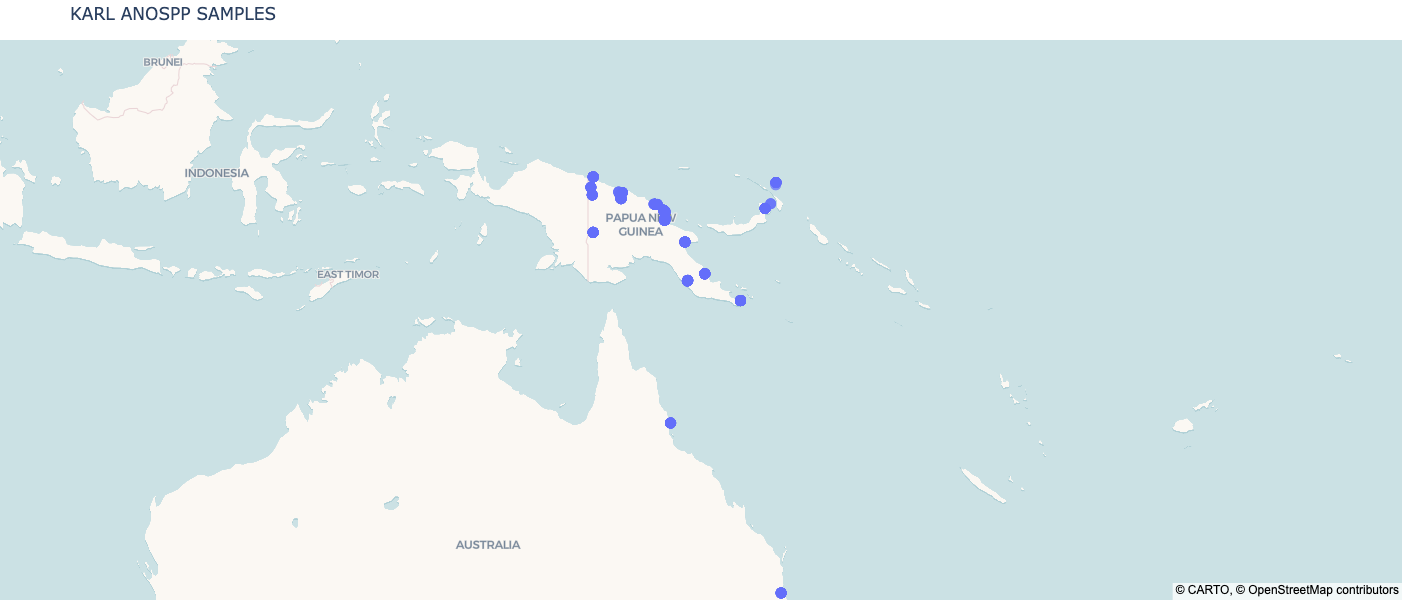

In [8]:
karl_samples = pd.read_csv('karl_manifest.txt', sep= '\t')

extent=[125, 171, -23, 0]
# Create interactive map
fig = px.scatter_map(
    karl_samples,
    lat='DECIMAL_LATITUDE',
    lon='DECIMAL_LONGITUDE',
    #color=color,
    #color_discrete_map=color_discrete_map_prepped,
    hover_data={
        'RACK_OR_PLATE_ID': True,
        'COLLECTION_LOCATION': True,
        'DECIMAL_LATITUDE': ':.4f',
        'DECIMAL_LONGITUDE': ':.4f',
        #color: True
    },
    title=f'KARL ANOSPP SAMPLES',
    zoom=3,
    height=600,
    width=1000
)

# Calculate center from extent
center_lat = (extent[2] + extent[3]) / 2
center_lon = (extent[0] + extent[1]) / 2

# Update map layout
fig.update_layout(
    map=dict(
        style="basic",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=3.5
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

# Update marker styling
fig.update_traces(
    marker=dict(
        size=12,
        opacity=0.7,
        #line=dict(width=1, color='black')
    )
)

#fig.show()

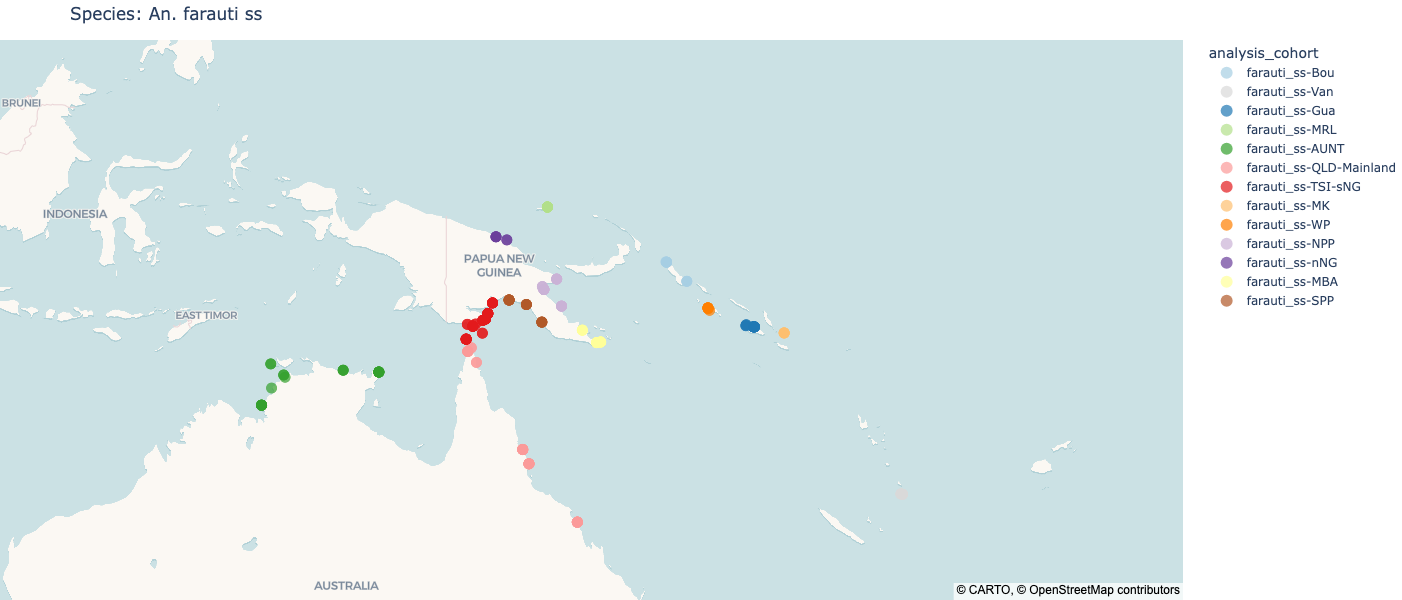

In [9]:
#An farauti ss
subset_df = df_samples.query('taxon_pca == "farauti_ss"')
color_data_unique_values = subset_df.analysis_cohort.unique()

# Make custom farauti pal
pal = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)-1).as_hex())#
pal.insert(1,"#d9d9d9") # add grey where vanuatu is
far_discrete_map_prepped = {
    v: c
    for v, c in zip(
        color_data_unique_values,
        cycle(pal),
        strict=False
    )
}


#plot_static_map(subset_df, title = "An. farauti ss", color="analysis_cohort", extent=[125, 171, -23, 0])
plot_interactive_map(subset_df, title = "An. farauti ss", color_discrete_map = far_discrete_map_prepped, color="analysis_cohort", extent=[125, 175, -13, -5])